<a href="https://colab.research.google.com/github/abino-w/-Executive-Hotel-Booking-/blob/main/Executive_Hotel_Booking_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Executive Hotel Booking — Full EDA Workflow
### Day 15 Assignment | End-to-End Exploratory Data Analysis

#import libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
palette = ["#1f4e79", "#2e86ab", "#f6b93b", "#e15554", "#3bb273", "#7768ae"]
sns.set_palette(palette)
pd.set_option('display.max_columns', None)


## 1. Data Understanding

In [11]:
df = pd.read_csv("/content/Day15_Executive_Hotel_Booking_EDA_Dataset - Copy.csv")
print("Shape:", df.shape)
df.head()


Shape: (25180, 35)


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,0,ARE,Direct,Direct,1,0,6,H,H,0,Non Refund,103.0,NaN,5,Contract,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,0,JPN,Groups,Direct,0,0,0,H,H,0,No Deposit,80.0,NaN,3,Contract,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,0,POL,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,53.0,NaN,2,Transient,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,0,CAN,Offline TA/TO,TA/TO,0,0,0,H,H,3,No Deposit,96.0,NaN,0,Contract,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,0,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,51.0,NaN,3,Group,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  object 
 13  Distribution_Cha

In [13]:
df.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,25180.0,182.200556,105.604452,0.00,91.00,182.000,273.0000,920.00
Weekend_Nights,25180.0,1.240429,1.063802,0.00,0.00,1.000,2.0000,3.00
Weekday_Nights,25180.0,2.451072,2.031003,0.00,1.00,2.000,4.0000,13.00
Adults,25180.0,2.198967,0.662379,1.00,2.00,2.000,2.0000,7.00
Children,25059.0,0.372122,0.657811,0.00,0.00,0.000,1.0000,6.00
Babies,25180.0,0.043050,0.225057,0.00,0.00,0.000,0.0000,2.00
Is_Repeated_Guest,25180.0,0.172597,0.377906,0.00,0.00,0.000,0.0000,1.00
Previous_Cancellations,25180.0,0.038642,0.251403,0.00,0.00,0.000,0.0000,3.00
Previous_Bookings,25180.0,1.117037,2.829046,0.00,0.00,0.000,0.0000,12.00
Booking_Changes,25180.0,0.601191,0.894293,0.00,0.00,0.000,1.0000,4.00


## 2. Data Quality Assessment


In [14]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})[missing > 0].sort_values('Missing_Count', ascending=False)


,Missing_Count,Missing_%
Company_ID,20729,82.32
Country,466,1.85
Agent_ID,304,1.21
Meal_Type,245,0.97
Satisfaction_Score,164,0.65
Children,121,0.48
Hotel_Location,106,0.42
ADR,82,0.33


In [15]:
print("Full duplicate rows:", df.duplicated().sum())
print("Duplicate Booking_IDs:", df['Booking_ID'].duplicated().sum())
df[df.duplicated(keep=False)].sort_values('Booking_ID').head(6)


Full duplicate rows: 180
Duplicate Booking_IDs: 180


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
23,HTL000016,Resort Hotel,Maldives,2024-10-27,2025-05-10,195,0,7,2,1.0,0,NaN,Direct,Direct,1,0,12,E,E,0,Non Refund,104.0,NaN,0,Contract,Undefined,7,168.65,1,0,4.12,Canceled,1,2025-05-16,1180.58
3538,HTL000016,Resort Hotel,Maldives,2024-10-27,2025-05-10,195,0,7,2,1.0,0,NaN,Direct,Direct,1,0,12,E,E,0,Non Refund,104.0,NaN,0,Contract,Undefined,7,168.65,1,0,4.12,Canceled,1,2025-05-16,1180.58
28,HTL000112,City Hotel,Barcelona,2024-03-06,2024-12-19,288,3,0,2,0.0,0,CHE,Groups,Corporate,1,0,2,C,C,1,No Deposit,166.0,1055.0,0,Contract,Undefined,3,109.98,0,2,3.75,Check-Out,0,2024-12-21,329.93
21428,HTL000112,City Hotel,Barcelona,2024-03-06,2024-12-19,288,3,0,2,0.0,0,CHE,Groups,Corporate,1,0,2,C,C,1,No Deposit,166.0,1055.0,0,Contract,Undefined,3,109.98,0,2,3.75,Check-Out,0,2024-12-21,329.93
8441,HTL000240,City Hotel,London,2024-05-15,2024-12-22,221,1,3,2,0.0,0,FRA,Corporate,Corporate,0,0,0,C,C,1,No Deposit,61.0,NaN,0,Contract,BB,4,93.30,0,3,4.18,Canceled,1,2024-12-25,373.18
452,HTL000240,City Hotel,London,2024-05-15,2024-12-22,221,1,3,2,0.0,0,FRA,Corporate,Corporate,0,0,0,C,C,1,No Deposit,61.0,NaN,0,Contract,BB,4,93.30,0,3,4.18,Canceled,1,2024-12-25,373.18


In [16]:
for col in ['Hotel_Type', 'Market_Segment', 'Meal_Type']:
    print(col, "->", sorted(df[col].dropna().unique().tolist()))
    print()


Hotel_Type -> ['CITY HOTEL', 'City Hotel', 'City hotel', 'Resort Hotel', 'city hotel']

Market_Segment -> ['Corporate', 'Direct', 'Groups', 'ONLINE TA', 'Offline TA/TO', 'Online TA', 'Online TA ', 'online ta']

Meal_Type -> [' B&B ', 'BB', 'BB ', 'FB', 'HB', 'SC', 'Undefined', 'Unknown', 'bb']



In [17]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lo) | (series > hi)).sum(), lo, hi

for col in ['ADR', 'Lead_Time_Days', 'Total_Nights', 'Estimated_Revenue']:
    n, lo, hi = iqr_outliers(df[col])
    print(f"{col:20s} bounds=({lo:8.1f}, {hi:8.1f})  outliers={n:5d} ({n/len(df)*100:.1f}%)")


ADR                  bounds=(    10.4,    264.3)  outliers=  359 (1.4%)
Lead_Time_Days       bounds=(  -182.0,    546.0)  outliers=    2 (0.0%)
Total_Nights         bounds=(    -2.5,      9.5)  outliers=  137 (0.5%)
Estimated_Revenue    bounds=(  -530.0,   1498.1)  outliers=  659 (2.6%)


In [18]:
bd = pd.to_datetime(df['Booking_Date'])
ad = pd.to_datetime(df['Arrival_Date'])
print("Rows with Arrival_Date < Booking_Date:", (ad < bd).sum())
print("Satisfaction scores outside 1-5:", ((df['Satisfaction_Score'] < 1) | (df['Satisfaction_Score'] > 5)).sum())


Rows with Arrival_Date < Booking_Date: 6
Satisfaction scores outside 1-5: 2


## 3. Data Cleaning & Preprocessing


In [19]:
clean = df.copy()

before = len(clean)
clean = clean.drop_duplicates()
print(f"Dropped {before - len(clean)} duplicate rows")

def norm(s):
    return str(s).strip() if pd.notna(s) else s

for c in ['Hotel_Type', 'Hotel_Location', 'Market_Segment', 'Meal_Type']:
    clean[c] = clean[c].apply(norm)

clean['Hotel_Type'] = clean['Hotel_Type'].str.title()
clean['Market_Segment'] = clean['Market_Segment'].apply(
    lambda x: 'Online TA' if str(x).strip().lower() == 'online ta' else x)
clean['Meal_Type'] = clean['Meal_Type'].replace(
    {'bb': 'BB', 'BB ': 'BB', 'B&B': 'BB', 'Unknown': np.nan, 'Undefined': np.nan})
clean['Hotel_Location'] = clean['Hotel_Location'].replace({'Unknown': np.nan})

print("Hotel_Type  :", clean['Hotel_Type'].unique())
print("Market_Segment:", clean['Market_Segment'].unique())
print("Meal_Type   :", clean['Meal_Type'].unique())


Dropped 180 duplicate rows
Hotel_Type  : ['City Hotel' 'Resort Hotel']
Market_Segment: ['Direct' 'Groups' 'Online TA' 'Offline TA/TO' 'Corporate']
Meal_Type   : ['HB' nan 'FB' 'SC' 'BB']


In [20]:
clean['Booking_Date'] = pd.to_datetime(clean['Booking_Date'], errors='coerce')
clean['Arrival_Date'] = pd.to_datetime(clean['Arrival_Date'], errors='coerce')
clean['Reservation_Status_Date'] = pd.to_datetime(clean['Reservation_Status_Date'], errors='coerce')

bad = clean['Arrival_Date'] < clean['Booking_Date']
print(f"Removing {bad.sum()} rows with impossible dates")
clean = clean[~bad]


Removing 6 rows with impossible dates


In [21]:
clean['Children'] = clean['Children'].fillna(0)
clean['Country'] = clean['Country'].fillna('Unknown')
clean['Hotel_Location'] = clean['Hotel_Location'].fillna('Unknown')
clean['Meal_Type'] = clean['Meal_Type'].fillna('Unknown')
clean['ADR'] = clean['ADR'].fillna(clean['ADR'].median())
clean['Satisfaction_Score'] = clean['Satisfaction_Score'].fillna(clean['Satisfaction_Score'].median())
clean['Has_Agent'] = clean['Agent_ID'].notna().astype(int)
clean['Has_Company'] = clean['Company_ID'].notna().astype(int)
clean['Satisfaction_Score'] = clean['Satisfaction_Score'].clip(1, 5)

print("Remaining missing values:\n", clean.isnull().sum()[clean.isnull().sum() > 0])
print("\nFinal cleaned shape:", clean.shape)


Remaining missing values:
 Agent_ID        300
Company_ID    20580
dtype: int64

Final cleaned shape: (24994, 37)


## 4. Univariate Analysis

/tmp/ipykernel_2473/3215932372.py:3: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.countplot(data=clean, x='Hotel_Type', hue='Hotel_Type', order=order, palette=palette, legend=False)


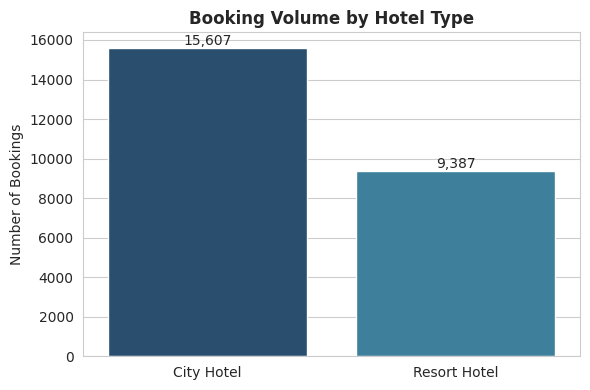

In [23]:
plt.figure(figsize=(6,4))
order = clean['Hotel_Type'].value_counts().index
ax = sns.countplot(data=clean, x='Hotel_Type', hue='Hotel_Type', order=order, palette=palette, legend=False)
plt.title("Booking Volume by Hotel Type", fontweight='bold')
plt.xlabel(""); plt.ylabel("Number of Bookings")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()


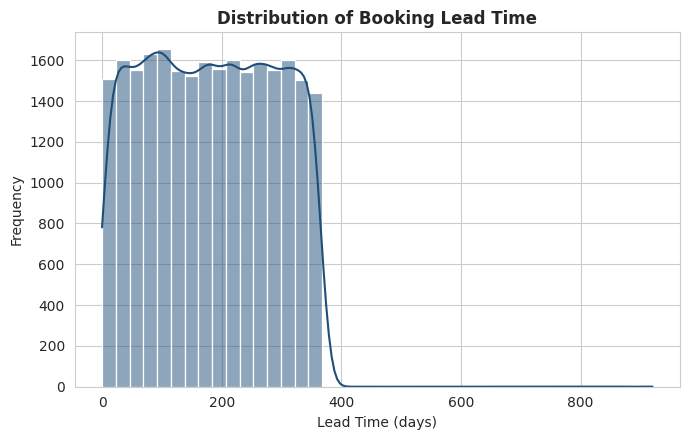

count    24994.000000
mean       182.236817
std        105.634124
min          0.000000
25%         91.000000
50%        182.000000
75%        273.000000
max        920.000000
Name: Lead_Time_Days, dtype: float64


In [24]:
plt.figure(figsize=(7,4.5))
sns.histplot(clean['Lead_Time_Days'], bins=40, kde=True, color=palette[0])
plt.title("Distribution of Booking Lead Time", fontweight='bold')
plt.xlabel("Lead Time (days)"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()
print(clean['Lead_Time_Days'].describe())


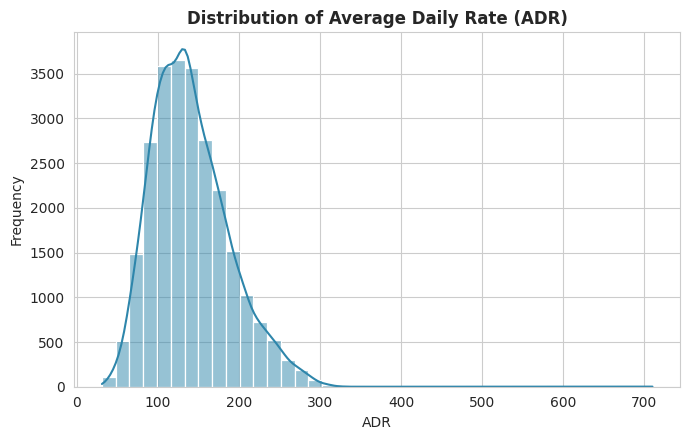

count    24994.000000
mean       140.585344
std         47.727679
min         30.800000
25%        105.692500
50%        134.400000
75%        168.965000
max        710.500000
Name: ADR, dtype: float64


In [25]:
plt.figure(figsize=(7,4.5))
sns.histplot(clean['ADR'], bins=40, kde=True, color=palette[1])
plt.title("Distribution of Average Daily Rate (ADR)", fontweight='bold')
plt.xlabel("ADR"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()
print(clean['ADR'].describe())


/tmp/ipykernel_2473/2063285034.py:3: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.countplot(data=clean, x='Reservation_Status', hue='Reservation_Status', order=res_order, palette=palette, legend=False)


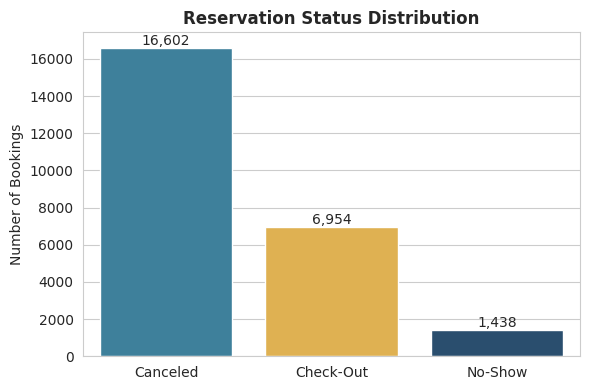

Overall cancellation rate: 72.18 %


In [26]:
plt.figure(figsize=(6,4))
res_order = clean['Reservation_Status'].value_counts().index
ax = sns.countplot(data=clean, x='Reservation_Status', hue='Reservation_Status', order=res_order, palette=palette, legend=False)
plt.title("Reservation Status Distribution", fontweight='bold')
plt.xlabel(""); plt.ylabel("Number of Bookings")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print("Overall cancellation rate:", round(clean['Is_Canceled'].mean()*100, 2), "%")


## 5. Bivariate & Group-wise Analysis

/tmp/ipykernel_2473/1544694187.py:3: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(x=cx.index, y=cx.values, hue=cx.index, palette=palette, legend=False)


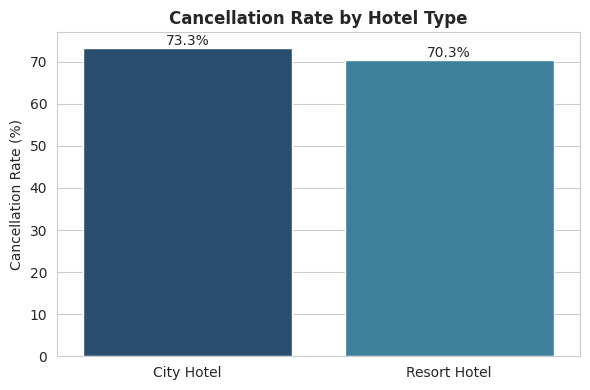

In [27]:
plt.figure(figsize=(6,4))
cx = clean.groupby('Hotel_Type')['Is_Canceled'].mean().reindex(order) * 100
ax = sns.barplot(x=cx.index, y=cx.values, hue=cx.index, palette=palette, legend=False)
plt.title("Cancellation Rate by Hotel Type", fontweight='bold')
plt.ylabel("Cancellation Rate (%)"); plt.xlabel("")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()


/tmp/ipykernel_2473/738829231.py:5: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  ax = sns.barplot(x=lt.index, y=lt.values, hue=lt.index, palette=palette, legend=False)


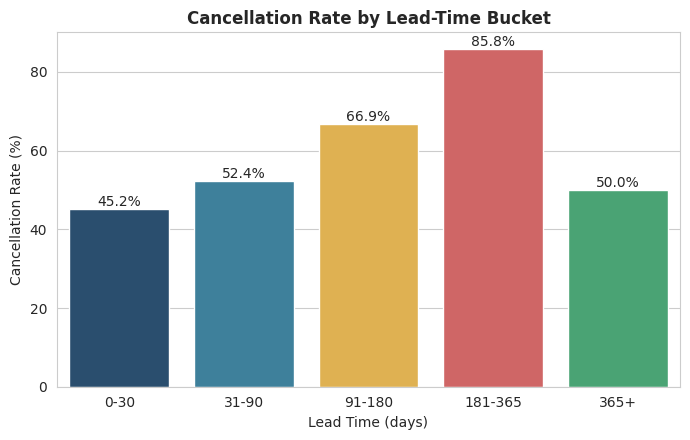

Is_Canceled
0    123.747483
1    204.783093
Name: Lead_Time_Days, dtype: float64


In [28]:
clean['Lead_Time_Bucket'] = pd.cut(clean['Lead_Time_Days'], bins=[-1,30,90,180,365,1000],
                                     labels=['0-30','31-90','91-180','181-365','365+'])
lt = clean.groupby('Lead_Time_Bucket', observed=True)['Is_Canceled'].mean() * 100
plt.figure(figsize=(7,4.5))
ax = sns.barplot(x=lt.index, y=lt.values, hue=lt.index, palette=palette, legend=False)
plt.title("Cancellation Rate by Lead-Time Bucket", fontweight='bold')
plt.xlabel("Lead Time (days)"); plt.ylabel("Cancellation Rate (%)")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(clean.groupby('Is_Canceled')['Lead_Time_Days'].mean())


/tmp/ipykernel_2473/602754833.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(data=clean, x='Market_Segment', y='ADR', hue='Market_Segment', order=seg_order, palette=palette, showfliers=False, legend=False)


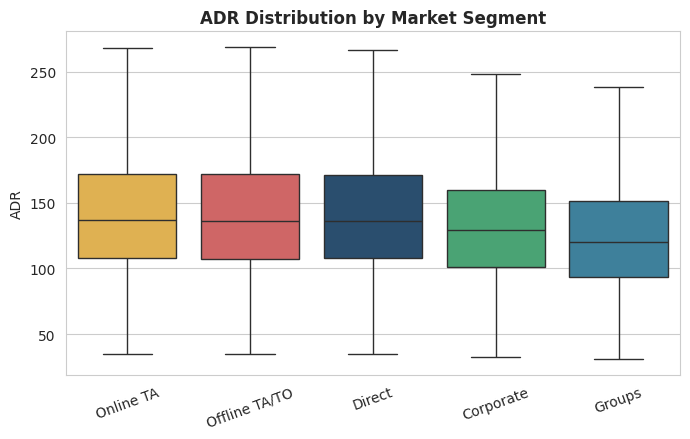

Market_Segment
Online TA        0.751083
Direct           0.712034
Offline TA/TO    0.704303
Groups           0.697906
Corporate        0.674808
Name: Is_Canceled, dtype: float64


In [29]:
seg_order = clean['Market_Segment'].value_counts().index
plt.figure(figsize=(7,4.5))
sns.boxplot(data=clean, x='Market_Segment', y='ADR', hue='Market_Segment', order=seg_order, palette=palette, showfliers=False, legend=False)
plt.title("ADR Distribution by Market Segment", fontweight='bold')
plt.xlabel(""); plt.ylabel("ADR"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()
print(clean.groupby('Market_Segment')['Is_Canceled'].mean().sort_values(ascending=False))


/tmp/ipykernel_2473/3645688091.py:3: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.barplot(x=dep.index, y=dep.values, hue=dep.index, palette=palette, legend=False)


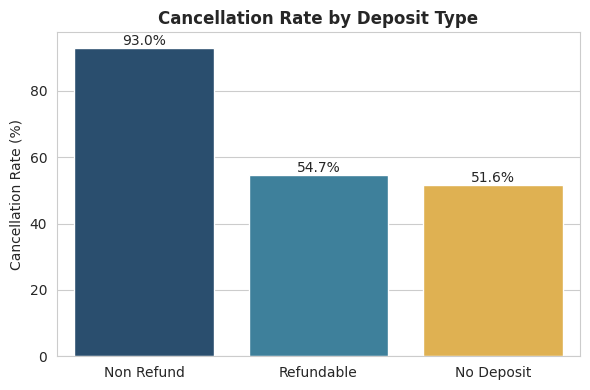

In [30]:
dep = clean.groupby('Deposit_Type')['Is_Canceled'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(6,4))
ax = sns.barplot(x=dep.index, y=dep.values, hue=dep.index, palette=palette, legend=False)
plt.title("Cancellation Rate by Deposit Type", fontweight='bold')
plt.ylabel("Cancellation Rate (%)"); plt.xlabel("")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()


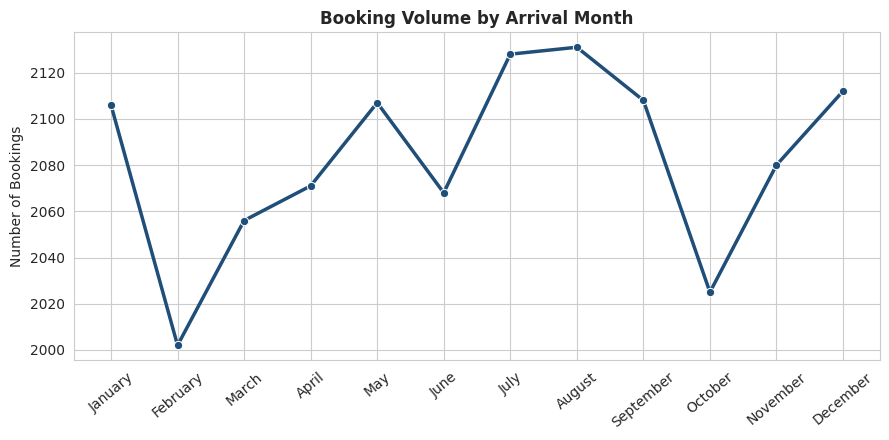

In [31]:
clean['Arrival_Month'] = clean['Arrival_Date'].dt.month_name()
month_order = ['January','February','March','April','May','June','July','August',
               'September','October','November','December']
mv = clean['Arrival_Month'].value_counts().reindex(month_order)
plt.figure(figsize=(9,4.5))
sns.lineplot(x=mv.index, y=mv.values, marker='o', color=palette[0], linewidth=2.5)
plt.title("Booking Volume by Arrival Month", fontweight='bold')
plt.xlabel(""); plt.ylabel("Number of Bookings"); plt.xticks(rotation=40)
plt.tight_layout(); plt.show()


/tmp/ipykernel_2473/1098956212.py:5: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(x=wb.index, y=wb.values, hue=wb.index, palette=palette, legend=False)


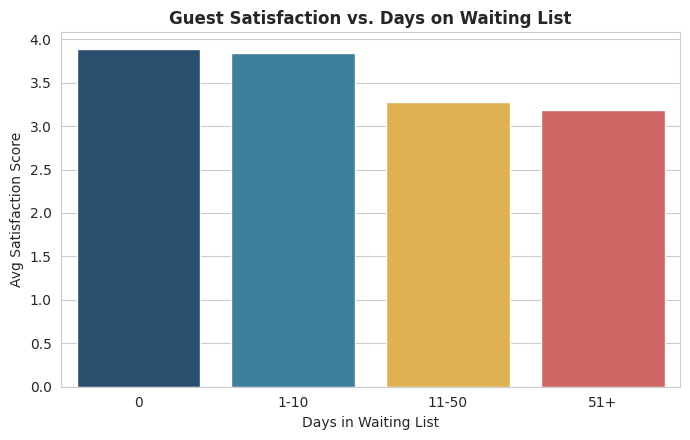

In [32]:
clean['wait_bucket'] = pd.cut(clean['Days_In_Waiting_List'], bins=[-1,0,10,50,400],
                                 labels=['0','1-10','11-50','51+'])
plt.figure(figsize=(7,4.5))
wb = clean.groupby('wait_bucket', observed=True)['Satisfaction_Score'].mean()
ax = sns.barplot(x=wb.index, y=wb.values, hue=wb.index, palette=palette, legend=False)
plt.title("Guest Satisfaction vs. Days on Waiting List", fontweight='bold')
plt.xlabel("Days in Waiting List"); plt.ylabel("Avg Satisfaction Score")
plt.tight_layout(); plt.show()


/tmp/ipykernel_2473/1709397723.py:3: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=top_c.values, y=top_c.index, hue=top_c.index, palette=palette, legend=False)


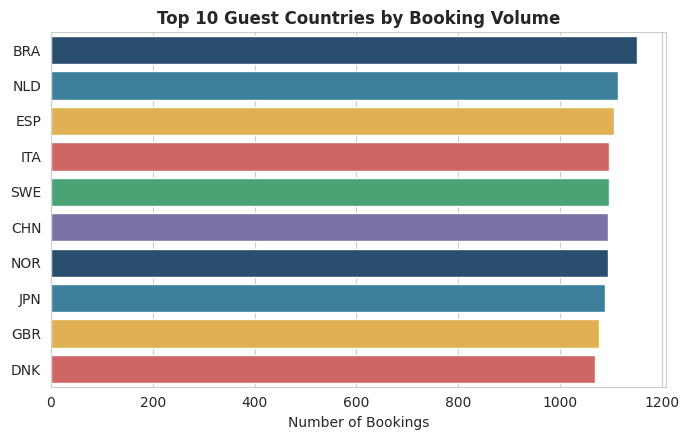

In [33]:
top_c = clean[clean['Country'] != 'Unknown']['Country'].value_counts().head(10)
plt.figure(figsize=(7,4.5))
sns.barplot(x=top_c.values, y=top_c.index, hue=top_c.index, palette=palette, legend=False)
plt.title("Top 10 Guest Countries by Booking Volume", fontweight='bold')
plt.xlabel("Number of Bookings"); plt.ylabel("")
plt.tight_layout(); plt.show()


/tmp/ipykernel_2473/3561500491.py:3: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=loc_rev.index, y=loc_rev.values/1000, hue=loc_rev.index, palette=palette, legend=False)


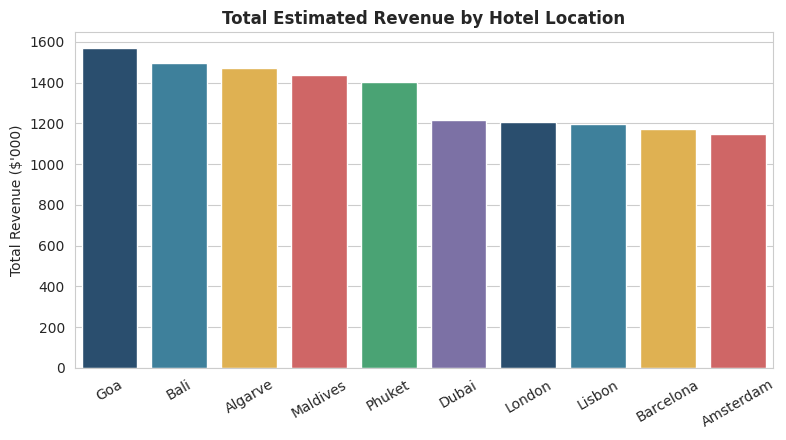

In [34]:
loc_rev = clean[clean['Hotel_Location'] != 'Unknown'].groupby('Hotel_Location')['Estimated_Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,4.5))
sns.barplot(x=loc_rev.index, y=loc_rev.values/1000, hue=loc_rev.index, palette=palette, legend=False)
plt.title("Total Estimated Revenue by Hotel Location", fontweight='bold')
plt.ylabel("Total Revenue ($'000)"); plt.xlabel(""); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


In [35]:
print("Revenue realized vs. tied up in cancellations:")
print(clean.groupby('Is_Canceled')['Estimated_Revenue'].agg(['sum','mean','count']))


Revenue realized vs. tied up in cancellations:
                    sum        mean  count
Is_Canceled                               
0            3779846.27  543.549938   6954
1            9600981.33  532.205174  18040


## 6. Correlation Analysis

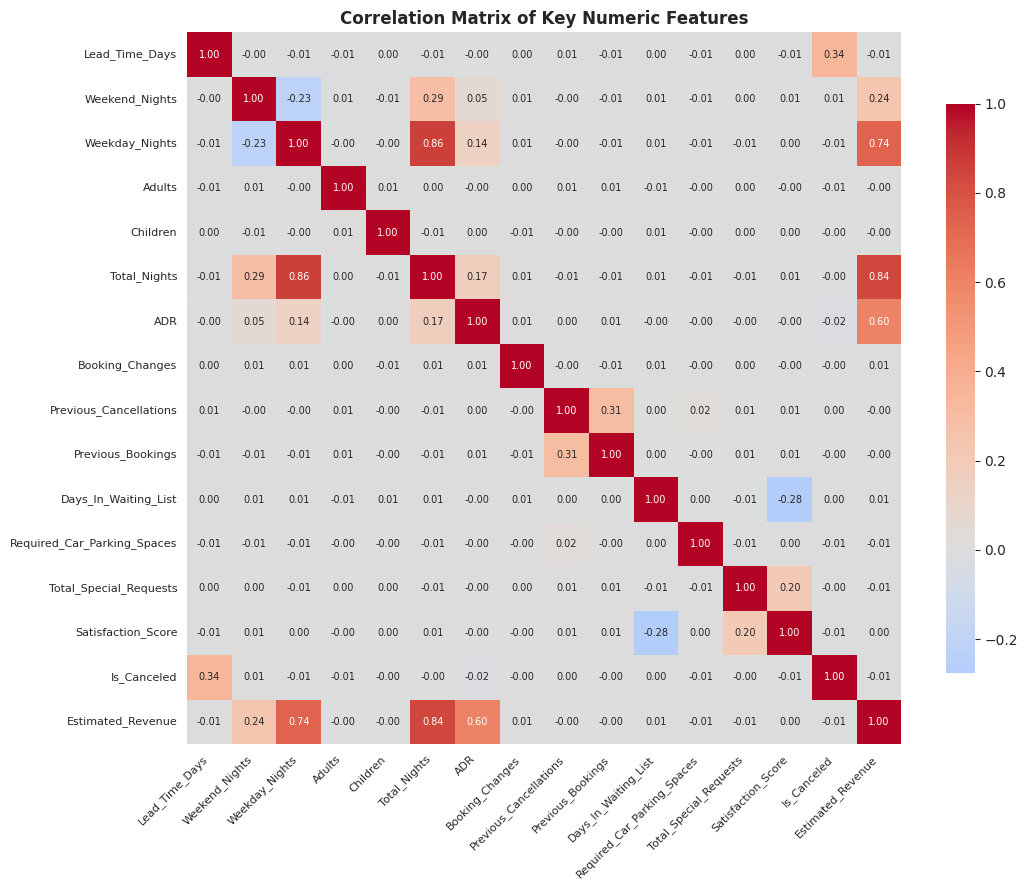

In [36]:
num_cols = ['Lead_Time_Days','Weekend_Nights','Weekday_Nights','Adults','Children','Total_Nights',
            'ADR','Booking_Changes','Previous_Cancellations','Previous_Bookings','Days_In_Waiting_List',
            'Required_Car_Parking_Spaces','Total_Special_Requests','Satisfaction_Score',
            'Is_Canceled','Estimated_Revenue']
corr = clean[num_cols].corr()
plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size":7}, cbar_kws={'shrink':0.8})
plt.title("Correlation Matrix of Key Numeric Features", fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()


**Key correlations to note:**
- `Lead_Time_Days` vs `Is_Canceled`: **+0.34** — bookings made far in advance are meaningfully
  more likely to be cancelled.
- `Total_Nights` vs `Estimated_Revenue`: **+0.84** and `ADR` vs `Estimated_Revenue`: **+0.60** —
  both length of stay and room rate drive revenue, as expected.
- `Days_In_Waiting_List` vs `Satisfaction_Score`: **-0.28** — longer waiting-list periods are
  associated with lower guest satisfaction.
- `Previous_Cancellations` vs `Previous_Bookings`: **+0.31** — guests with a cancellation history
  tend to also have more prior bookings overall (frequent bookers, not necessarily "bad" guests).


## 7. Key Business Insights

1. **Cancellation rate is extremely high — 72.2% of all bookings end in cancellation or no-show.**
   City Hotels (73.3%) cancel slightly more often than Resort Hotels (70.3%), and the effect is
   consistent across nearly every market segment and customer type, suggesting a structural
   booking-process issue rather than an isolated segment problem.

2. **Longer lead time is the single strongest driver of cancellation.** Cancelled bookings carry
   an average lead time of ~205 days vs. ~124 days for completed stays (correlation +0.34), and
   the cancellation rate climbs steadily across lead-time buckets. Guests who book far in advance
   are much more likely to change plans or be intentionally speculative bookers.

3. **Deposit type is a near-perfect cancellation signal.** "Non-Refund" bookings cancel at a
   striking **92.9%** rate, versus ~52–55% for "Refundable" and "No Deposit" bookings — the
   opposite of what a refund policy is meant to achieve, and worth a policy or data-integrity review.

4. **Revenue is heavily exposed to cancellations.** Cancelled/no-show bookings account for **72%
   of all reservations** and represent **$9.6M in estimated revenue that was booked but not
   realized**, versus $3.8M actually collected from completed stays — a very large gap between
   booked and realized revenue.

5. **Guest satisfaction erodes with waiting-list delays.** Average satisfaction drops from 3.88
   (no wait) to 3.19 (51+ days on the waiting list), and Online TA — the largest booking channel
   by volume — also carries the highest cancellation rate (75.1%) among market segments.


## 8. Recommendations for Management

1. **Investigate the "Non-Refund" deposit anomaly immediately.** A 92.9% cancellation rate on
   non-refundable bookings is counter-intuitive and may indicate either a data/labeling issue, a
   channel gaming the refund policy, or a broken enforcement process — resolving this could be the
   single highest-leverage fix in the dataset.

2. **Tighten cancellation policies for long-lead-time bookings.** Introduce partial pre-payment or
   confirmation call-backs for reservations made more than 180 days in advance, where cancellation
   risk is highest.

3. **Prioritize Online TA channel management.** As both the highest-volume and highest-cancellation
   segment, renegotiate terms with OTAs (e.g., shorter free-cancellation windows) or add overbooking
   buffers specifically for this channel.

4. **Reduce waiting-list dwell time.** Since satisfaction drops sharply after 10+ days on a waiting
   list, set an internal SLA to confirm or reject waitlisted requests within a defined window.

5. **Build a dynamic overbooking model using lead time and deposit type as predictors**, since these
   are the two strongest available signals of cancellation risk, to protect realized revenue.

6. **Standardize data capture at the source.** Inconsistent casing/whitespace in `Hotel_Type`,
   `Market_Segment`, and `Meal_Type`, plus 180 duplicate records, point to booking-system input
   validation gaps that should be fixed upstream, not just cleaned downstream.

7. **Focus retention/marketing spend on Corporate and Groups segments**, which show the lowest
   cancellation rates (67.5% and 69.8% respectively) and more stable, predictable revenue relative
   to Online TA and Direct channels.
